In [31]:
import numpy as np
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch.nn.functional as F

In [32]:
mnist_train = datasets.MNIST(
    root="./datasets",
    train=True,
    transform=transforms.ToTensor(),
    download=True
)
print("MNIST train dataset shape: ", mnist_train.data.shape)


MNIST train dataset shape:  torch.Size([60000, 28, 28])


In [33]:
mnist_test = datasets.MNIST(
    root="./datasets",
    train=False,
    transform=transforms.ToTensor(),
    download=True
)
print("MNIST test dataset shape: ", mnist_test.data.shape)

MNIST test dataset shape:  torch.Size([10000, 28, 28])


In [34]:
image, label = mnist_train[3]
print(image.shape)
image = image.reshape([28, 28])
print(image.shape)

torch.Size([1, 28, 28])
torch.Size([28, 28])


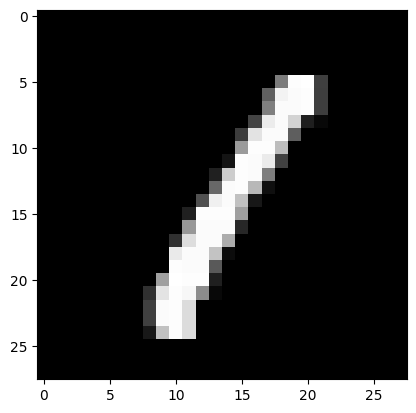

1


In [35]:
plt.imshow(image, cmap="gray")
plt.show()
print(label)

In [36]:
train_loader = torch.utils.data.DataLoader(
    mnist_train,
    batch_size=100,
    shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    mnist_test,
    batch_size=100,
    shuffle=False
)

In [37]:
data_train_iter = iter(train_loader)
image, labels = data_train_iter.__next__()
print(image.shape)
print(labels.shape)

torch.Size([100, 1, 28, 28])
torch.Size([100])


In [38]:
x = image.view(-1, 28*28)
print(x.shape)

torch.Size([100, 784])


$$
y_1 = \sum_i{x_iw_{i,1} + b_1}
$$

$$
y = xW + b
$$

In [39]:
W = torch.randn(784,10)/np.sqrt(784) # Xavier initialization

[Xe VS He habr](https://habr.com/ru/articles/932852/)


[Xavier in geeksforgeeks](https://www.geeksforgeeks.org/deep-learning/xavier-initialization/)


[Xe VS He Medium](https://medium.com/thedeephub/he-and-xavier-weight-initialization-functions-acedc5322ce5)

In [40]:
W.requires_grad = True
b = torch.zeros(10, requires_grad=True)
W, b

(tensor([[ 0.0063,  0.0232,  0.0283,  ..., -0.0012, -0.0234, -0.0635],
         [-0.0163, -0.0355,  0.0015,  ..., -0.0400, -0.0276, -0.0167],
         [-0.0962,  0.0446, -0.0440,  ..., -0.0368, -0.0964, -0.0101],
         ...,
         [-0.0979,  0.0636,  0.0112,  ...,  0.0163,  0.0240, -0.0202],
         [-0.0267,  0.0163,  0.0062,  ..., -0.0269, -0.0491, -0.0487],
         [ 0.0336, -0.0249, -0.0215,  ...,  0.0431,  0.0354,  0.0440]],
        requires_grad=True),
 tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], requires_grad=True))

In [42]:
y = torch.matmul(x, W) + b
print((y[0, :]))

tensor([ 0.1507,  0.1737,  0.1094, -0.1773,  0.1473,  0.0850, -0.0057,  0.4169,
         0.0350,  0.0041], grad_fn=<SelectBackward0>)


$$
p(y_i) = softmax(y_i) = \frac{exp(y_i)}{\sum_i{exp(y_j)}}
$$